# Predictive Analytics: SVR trained on the residual over base_demand

We predict taxi pickup demand (`Total_Trip_Start`) with an SVR, at **every spatial and
temporal granularity** the discretization in `1.4` produces — three spatial levels (H3 Res-7,
Census Tract, Community Area) crossed with two temporal levels (hourly, daily).

While `3.2a PredictionSVM_Standard.ipynb` fits an SVR to predict log1p(demand) directly, this notebook instead fits the SVR on the *residual* rather than the total.
The target becomes the log-space correction log1p(demand) - log1p(base_demand), reconstructed as demand_hat = expm1(log1p(base_demand) + correction_hat), with a full, independent kernel scan and hyperparameter search run *directly on the residual target*, for all 6 levels, with the winner reported on the validation split exactly as `3.2a` does for its own winners. The held-out **test** split is never touched here — it is used once, in `3.4`, for the SVM-vs-NN comparison. The residual target has a much smaller scale/variance than `log1p(demand)`, so hyperparameters tuned for the original target are not necessarily the right
ones here.

In [1]:
# Run the common ground notebook to set up the environment and import necessary libraries and define functions and variables that are used in this notebook.
%run "3.2 PredictionCommonGround.ipynb"

In [2]:
import gc
import warnings
from pathlib import Path 

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from joblib import Parallel, delayed
from sklearn.svm import SVR
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import KFold, ParameterGrid
from sklearn.exceptions import ConvergenceWarning
from sklearn.metrics import mean_absolute_error, r2_score, mean_squared_error

warnings.filterwarnings("ignore", category=UserWarning)
warnings.filterwarnings("ignore", category=ConvergenceWarning)

np.random.seed(RANDOM_STATE)

MODELS_DIR = Path("..") / "models_predictions" / "SVR" / "residual"
SVR_DIR = MODELS_DIR / "models"
DIRECT_SVR_DIR = Path("..") / "models_predictions" / "SVR" / "standard" / "models"  # 3.2a's models and level_comparison

N_CV_SPLITS = 3  # folds for the manual residual grid search (matches 3.2a's GridSearchCV cv=3)

# sklearn's SVR defaults to max_iter=-1 (unbounded LIBSVM iterations). Some (C, gamma) combinations
# fail to converge in reasonable time. A large but finite cap ends a non-converging fit.
SVR_MAX_ITER = 50_000

## 1. The six levels

SPATIAL_LEVELS, TEMPORAL_LEVELS, LEVELS, and load_splits get imported from  `3.2 Prediction_CommonGround.ipynb`. 

Each split is at `data/prediction_split/<spatial>/<temporal>/{train,val,test}.parquet`


In [3]:
# Per-level training overview (units, rows, mean demand, zero share); helper in Common Ground.
overview_table()

,spatial,temporal,units,train rows,mean demand,zero %
0,h3_7,hourly,108,1117152,2.43,93.25
1,h3_7,daily,108,46548,58.35,78.94
2,census,hourly,496,5130624,0.53,96.54
3,census,daily,496,213776,12.70,88.25
4,community,hourly,77,796488,7.58,44.64
5,community,daily,77,33187,181.88,0.81


## 2. Feature sets

All `feature_sets` get imported from `3.2 Prediction_CommonGround.ipynb`


In [4]:
# Feature set sizes for each temporal level; helper in Common Ground.
print_feature_set_sizes()

hourly  {'basic': 12, 'basic+poi': 26, 'basic+weather': 17, 'basic+poi+weather': 31}
daily   {'basic': 10, 'basic+poi': 24, 'basic+weather': 15, 'basic+poi+weather': 29}


## 3. Pipeline
### Kernel scan and grid search on the residual target

**This is the one place in the pipeline that structurally diverges from** `3.2a` (every other
section (registry, feature sets, training-loop shape, level-comparison table) is unchanged):

**Residual target, not log1p(y) directly.** 

The model is fit to log1p(demand) - log1p(base_demand) and reconstructed as demand_hat = expm1(log1p(base_demand) + correction_hat). This has a built-in floor: a correction of exactly 0 everywhere reproduces base_demand exactly, i.e. skill = 0. Any improvement found here is a genuine addition. 

`3.2a` scores by computing to_counts(y_log) vs. to_counts(estimator.predict(X)) (y_log = log1p(demand)). If the model predicts a *residual* instead, turning that back into counts needs the row's base_demand, which a standard sklearn scorer never sees. That is why a custom GridSearch with KFold is needed.

In [5]:
def find_best_kernel_residual(Xs, y_resid_s, base_log1p_val, X_val, y_val_true):
    """Scan kernels at fixed hyperparameters on the residual target; pick by validation R2 in count
    space after adding base_demand's log1p back in."""
    val_r2 = {}
    for kernel in KERNELS:
        svr = SVR(kernel=kernel, C=1.0, gamma="scale", cache_size=500, max_iter=SVR_MAX_ITER)
        svr.fit(Xs, y_resid_s)
        log1p_pred = np.clip(base_log1p_val + svr.predict(X_val), -LOG_CEILING, LOG_CEILING)
        val_r2[kernel] = r2_score(y_val_true, to_counts(log1p_pred))
        print(f"      SVR({kernel:6s}) val R2 = {val_r2[kernel]:12.4f}")
    best = max(val_r2, key=val_r2.get)
    print(f"      -> best kernel: {best}")
    return best, val_r2


def _score_params(params, X_all, base_log1p_all, y_resid_all, y_true_all, kernel, fold_splits):
    """One parameter combination's mean CV MAE, all folds fit sequentially inside the worker --
    parallelism is across parameter combinations (9 for rbf/linear, 18 for poly), not folds.

    The ConvergenceWarning filter set in cell 1 does NOT reach here: joblib's spawn-based worker
    processes (the default on macOS) do not inherit the parent process's runtime
    warnings.filterwarnings() state, only whatever is set inside the code that actually runs in the
    worker -- confirmed by direct reproduction. So the filter is set again, right here.
    """
    warnings.filterwarnings("ignore", category=ConvergenceWarning)
    fold_maes = []
    for train_idx, val_idx in fold_splits:
        model = SVR(kernel=kernel, cache_size=500, max_iter=SVR_MAX_ITER, **params)
        model.fit(X_all[train_idx], y_resid_all[train_idx])
        log1p_pred = np.clip(base_log1p_all[val_idx] + model.predict(X_all[val_idx]),
                              -LOG_CEILING, LOG_CEILING)
        #fold_maes.append(mean_absolute_error(y_true_all[val_idx], to_counts(log1p_pred)))
        fold_maes.append(mean_absolute_error(y_true_all[val_idx], to_counts(log1p_pred)))
    return params, float(np.mean(fold_maes))


def grid_search_svr_residual(X_all, base_log1p_all, y_resid_all, y_true_all, kernel,
                             n_splits=N_CV_SPLITS, seed=RANDOM_STATE, n_jobs=-1):
    """Manual K-fold CV over C/gamma (+ degree for poly), scored by count-space MAE after
    reconstructing counts from the residual prediction. Refits on the full sample at the winning
    parameters, exactly as GridSearchCV's refit=True does in 3.2a.

    Takes the already-scaled feature matrix and the raw base_demand/target arrays separately,
    rather than a single DataFrame -- `base_demand` is itself one of the input features, so scaling
    it in place and then reading it back out for the log1p offset would silently use the scaled
    (mean 0, std 1) value instead of the real historical mean.

    Parallelized across parameter combinations with joblib -- sklearn's GridSearchCV(n_jobs=-1),
    which this replaces, does the same. A purely sequential loop here means one slow-to-converge
    (C, gamma) combination (LIBSVM's SMO solver can be much slower on some settings than others,
    especially on a target as bimodal as the residual is at heavily zero-inflated levels) blocks
    every other combination behind it instead of running alongside them."""
    param_grid = {"C": [1, 10, 50], "gamma": ["scale", 0.05, 0.2]}
    if kernel == "poly":
        param_grid["degree"] = [2, 3]

    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    fold_splits = list(kf.split(X_all))

    results = Parallel(n_jobs=n_jobs)(
        delayed(_score_params)(params, X_all, base_log1p_all, y_resid_all, y_true_all, kernel, fold_splits)
        for params in ParameterGrid(param_grid)
    )
    best_params, best_mae = min(results, key=lambda r: r[1])

    print(f"      best params: {best_params}")
    final_model = SVR(kernel=kernel, cache_size=500, max_iter=SVR_MAX_ITER, **best_params)
    final_model.fit(X_all, y_resid_all)
    return final_model, best_params


def train_feature_set_residual(df_train, df_val_s, features, spatial, temporal, set_name):
    """Fit one (level, feature set) configuration on the residual target and return its bundle."""
    scaler = StandardScaler().fit(df_train[features])
    X_val = scaler.transform(df_val_s[features])
    base_log1p_val = np.log1p(df_val_s["base_demand"].values)
    y_val = df_val_s[TARGET].values

    scan = balanced_sample(df_train, N_SCAN)
    Xs = scaler.transform(scan[features])
    y_resid_s = np.log1p(scan[TARGET].values) - np.log1p(scan["base_demand"].values)
    best_kernel, kernel_r2 = find_best_kernel_residual(Xs, y_resid_s, base_log1p_val, X_val, y_val)

    sample = balanced_sample(df_train, N_GRID)
    X_grid = scaler.transform(sample[features])
    base_log1p_grid = np.log1p(sample["base_demand"].values)
    y_resid_grid = np.log1p(sample[TARGET].values) - base_log1p_grid
    y_true_grid = sample[TARGET].values
    tuned, best_params = grid_search_svr_residual(
        X_grid, base_log1p_grid, y_resid_grid, y_true_grid, best_kernel)

    log1p_pred_val = np.clip(base_log1p_val + tuned.predict(X_val), -LOG_CEILING, LOG_CEILING)
    val_metrics = score(y_val, to_counts(log1p_pred_val),
                        f"SVR-residual {spatial}/{temporal} ({set_name}, {best_kernel})")

    return {
        "model": tuned,
        "scaler": scaler,
        "features": features,
        "spatial": spatial,
        "temporal": temporal,
        "spatial_key": SPATIAL_LEVELS[spatial],
        "feature_set": set_name,
        "kernel": best_kernel,
        "kernel_r2": kernel_r2,
        "best_params": best_params,
        "target": "residual_log1p_over_base_demand",
        "val_metrics": val_metrics,
    }

## 4. Training

One pass per level: load the splits once, train all four feature sets, pick the winner on validation, evaluate that winner once on the full validation split, save it.

The result is 32 bundles, keyed by (spatial, temporal, feature_set)


In [6]:
#| label: tbl-svr-residual2-val-metrics
#| tbl-cap: "Validation performance per level: baselines vs. the tuned residual-on-baseline SVR for each feature set (hyperparameters searched directly on the residual target)."
SVR_DIR.mkdir(parents=True, exist_ok=True)

bundles = {}      # (spatial, temporal, feature_set) -> bundle
val_rows = []

for spatial, temporal in LEVELS:
    print(f"\n{'=' * 70}\n{spatial} / {temporal}\n{'=' * 70}")
    # The test split is deliberately NOT loaded here. It is touched only in
    # 3.4 ModelPerformanceVisualization, after all model selection is done.
    df_train, df_val, _ = load_splits(spatial, temporal)
    key = SPATIAL_LEVELS[spatial]

    df_val_s = df_val.sample(n=min(N_VAL_SUBSAMPLE, len(df_val)), random_state=RANDOM_STATE)
    y_val_s = df_val_s[TARGET].values
    print(f"train {len(df_train):>9,} | val {len(df_val):>9,} (subsample {len(df_val_s):,}) "
          f"| zeros {(df_train[TARGET] == 0).mean():.1%}")

    for name, metrics in [
        ("Baseline: always zero", score(y_val_s, np.zeros(len(y_val_s)), "Baseline: always zero")),
        ("Baseline: historical mean (base_demand)",
         score(y_val_s, df_val_s["base_demand"].values, "Baseline: historical mean (base_demand)")),
    ]:
        val_rows.append({"spatial": spatial, "temporal": temporal, **metrics})

    for set_name, features in feature_sets(temporal).items():
        print(f"\n   feature set: {set_name} ({len(features)} features)")
        bundle = train_feature_set_residual(df_train, df_val_s, features, spatial, temporal, set_name)
        bundles[(spatial, temporal, set_name)] = bundle
        val_rows.append({"spatial": spatial, "temporal": temporal, **bundle["val_metrics"]})
        print(f"      val: MAE={bundle['val_metrics']['MAE']:.3f}  "
              f"R2={bundle['val_metrics']['R2']:.4f}")

    # winner for this level, chosen on the validation subsample R2, then evaluated
    # once on the FULL validation split. The test split is never used here.
    level_sets = {k[2]: b for k, b in bundles.items() if k[0] == spatial and k[1] == temporal}
    best_set = max(level_sets, key=lambda s: level_sets[s]["val_metrics"]["R2"])
    best = level_sets[best_set]
    print(f"\n   -> winner: {best_set} ({best['kernel']}); scoring on the full validation split...")

    y_val_full = df_val[TARGET].values
    base_val = score(y_val_full, df_val["base_demand"].values, "Baseline: historical mean (base_demand)")

    X_val_full = best["scaler"].transform(df_val[best["features"]])
    base_log1p_val_full = np.log1p(df_val["base_demand"].values)
    log1p_pred_val = np.clip(base_log1p_val_full + best["model"].predict(X_val_full), -LOG_CEILING, LOG_CEILING)
    val_pred = to_counts(log1p_pred_val)
    model_val = score(y_val_full, val_pred, f"SVR-residual ({best_set}, {best['kernel']})")

    best["val_full_metrics"] = model_val
    best["baseline_val_metrics"] = base_val
    best["skill"] = skill(model_val, base_val)
    best["is_level_winner"] = True

    print(f"      val (full): MAE={model_val['MAE']:.3f}  R2={model_val['R2']:.4f}  "
          f"skill vs base_demand: {best['skill']['skill_MAE']:+.1%} MAE")

    # persist the winner; 3.4 reloads it to score once on the held-out test split
    out_dir = SVR_DIR / spatial / temporal
    out_dir.mkdir(parents=True, exist_ok=True)
    joblib.dump(best, out_dir / "best.joblib")

    del df_train, df_val, df_val_s, val_pred
    gc.collect()

print(f"\n\nTrained {len(bundles)} configurations across {len(LEVELS)} levels.")

val_metrics = (pd.DataFrame(val_rows)
               .set_index(["spatial", "temporal", "Model"])
               .round(4))
val_metrics


h3_7 / hourly
train 1,117,152 | val   448,416 (subsample 50,000) | zeros 93.2%

   feature set: basic (12 features)


      SVR(linear) val R2 =       0.8997


      SVR(poly  ) val R2 =       0.9002


      SVR(rbf   ) val R2 =       0.9170
      -> best kernel: rbf


      best params: {'C': 1, 'gamma': 0.05}


...

      SVR(rbf   ) val R2 =       0.9612
      -> best kernel: linear


      best params: {'C': 1, 'gamma': 'scale'}


      val: MAE=33.188  R2=0.9675

   -> winner: basic+weather (linear); scoring on the full validation split...


      val (full): MAE=34.254  R2=0.9698  skill vs base_demand: +5.3% MAE


Trained 24 configurations across 6 levels.


MAE  \
spatial   temporal Model                                                          
h3_7      hourly   Baseline: always zero                                 2.9460   
                   Baseline: historical mean (base_demand)               0.8665   
                   SVR-residual h3_7/hourly (basic, rbf)                 0.9168   
                   SVR-residual h3_7/hourly (basic+poi, linear)          1.1931   
                   SVR-residual h3_7/hourly (basic+weather, linear)      0.8759   
                   SVR-residual h3_7/hourly (basic+poi+weather, li...    1.4700   
          daily    Baseline: always zero                                72.4800   
                   Baseline: historical mean (base_demand)              15.8295   
                   SVR-residual h3_7/daily (basic, poly)                15.8068   
                   SVR-residual h3_7/daily (basic+poi, linear)          15.6367   
                   SVR-residual h3_7/daily (basic+weather, rbf)         15.3835   
                   SVR-residual h3_7/daily (basic+poi+weather, rbf)     15.3466   
census    hourly   Baseline: always zero                                 0.7180   
                   Baseline: historical mean (base_demand)               0.2658   
                   SVR-residual census/hourly (basic, linear)            0.3461   
                   SVR-residual census/hourly (basic+poi, rbf)           0.3174   
                   SVR-residual census/hourly (basic+weather, rbf)       0.3223   
                   SVR-residual census/hourly (basic+poi+weather, ...    0.3178   
          daily    Baseline: always zero                                15.8353   
                   Baseline: historical mean (base_demand)               3.8663   
                   SVR-residual census/daily (basic, linear)             3.8972   
                   SVR-residual census/daily (basic+poi, rbf)            3.9212   
                   SVR-residual census/daily (basic+weather, rbf)        3.9129   
                   SVR-residual census/daily (basic+poi+weather, rbf)    3.8368   
community hourly   Baseline: always zero                                 8.9033   
                   Baseline: historical mean (base_demand)               2.5332   
                   SVR-residual community/hourly (basic, linear)         2.6508   
                   SVR-residual community/hourly (basic+poi, linear)     3.8691   
                   SVR-residual community/hourly (basic+weather, l...    2.6073   
                   SVR-residual community/hourly (basic+poi+weathe...    2.5688   
          daily    Baseline: always zero                               214.2191   
                   Baseline: historical mean (base_demand)              36.1879   
                   SVR-residual community/daily (basic, linear)         34.2617   
                   SVR-residual community/daily (basic+poi, linear)     35.2736   
                   SVR-residual community/daily (basic+weather, li...   34.2541   
                   SVR-residual community/daily (basic+poi+weather...   33.1882   

                                                                           RMSE  \
spatial   temporal Model                                                          
h3_7      hourly   Baseline: always zero                                21.1367   
                   Baseline: historical mean (base_demand)               5.9440   
                   SVR-residual h3_7/hourly (basic, rbf)                 5.9338   
                   SVR-residual h3_7/hourly (basic+poi, linear)          7.9867   
                   SVR-residual h3_7/hourly (basic+weather, linear)      5.5005   
                   SVR-residual h3_7/hourly (basic+poi+weather, li...   11.3262   
          daily    Baseline: always zero                               401.6876   
                   Baseline: historical mean (base_demand)              89.4453   
                   SVR-residual h3_7/daily (basic, poly)                91.1221   
        

## 5. Comparing the levels

Raw MAE is not comparable across levels. Mean demand runs from about 2.5 trips per hexagon-hour at
h3_7/hourly to over 200 trips per area-day at community/daily. On raw MAE the finest grid would always look best simply because there is less to be wrong about.

The **skill score** fixes this: `1 - MAE_model / MAE_base_demand`. 
- It asks whether the SVR beats the historical-mean baseline *on its own ground*, and that comparison transfers across levels. 
- A skill of 0 means the model has learned nothing the historical average did not already know; 
- negative means it is actively worse.
- Higher skill score -> better prediction


In [7]:
#| label: tbl-svr-residual2-level-comparison
#| tbl-cap: "Winning residual-on-baseline SVR per level, with skill against the historical-mean baseline."
# Kept as an in-memory DataFrame only -- nothing reads this notebook's own level_comparison back in,
# unlike 3.2a's (which 3.2b itself reads below for the direct-vs-residual comparison), so no CSV
# is written here.
level_comparison = build_level_comparison(bundles)
level_comparison.round(4).reset_index(drop=True)

,spatial,temporal,feature_set,kernel,base_MAE,val_MAE,val_RMSE,val_R2,skill_MAE,skill_RMSE
0,community,daily,basic+weather,linear,36.1879,34.2541,118.3257,0.9698,0.0534,0.0891
1,h3_7,daily,basic+poi,linear,15.8295,15.6367,84.9372,0.9538,0.0122,0.0504
2,census,daily,basic+poi+weather,rbf,3.8284,3.8174,26.1691,0.9399,0.0029,0.0111
3,h3_7,hourly,basic+weather,linear,0.8861,0.8838,5.5285,0.9336,0.0026,0.0865
4,community,hourly,basic+poi+weather,rbf,2.5250,2.5498,9.2293,0.9316,-0.0098,-0.0259
5,census,hourly,basic,linear,0.2438,0.3221,1.9674,0.8915,-0.3214,0.0071


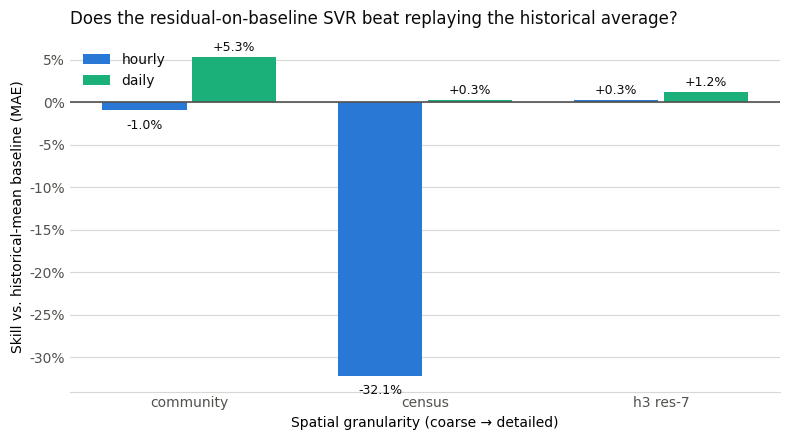

In [8]:
#| label: fig-svr-residual2-skill-by-level
#| fig-cap: "Residual-on-baseline SVR skill against the historical-mean baseline, by spatial and temporal granularity."
plot_skill_by_level(level_comparison, title="Does the residual-on-baseline SVR beat replaying the historical average?")

## 6. Direct vs. residual: The Comparison

Section 5 compared this notebook's own 6 levels against each other. The comparison that actually
matters is against `3.2a`'s own winning configuration per level: both notebooks report on the same
validation split (each level's winner scored on its full validation set), so this is exact, not
approximate. The held-out test split is used only later, in `3.4`.

In [9]:
#| label: tbl-svr-direct-vs-residual-final
#| tbl-cap: "Direct SVR (3.2a) vs. residual-on-baseline SVR trained from scratch (this notebook), per level, on the validation split."
direct_comparison = pd.read_csv(DIRECT_SVR_DIR / "level_comparison.csv")

final_comparison = level_comparison.merge(
    direct_comparison[["spatial", "temporal", "skill_MAE", "val_MAE"]],
    on=["spatial", "temporal"], suffixes=("_residual", "_direct"),
)
final_comparison["delta_skill_MAE"] = (
    final_comparison["skill_MAE_residual"] - final_comparison["skill_MAE_direct"]
)
final_comparison = final_comparison.sort_values("delta_skill_MAE", ascending=False)
final_comparison[["spatial", "temporal", "feature_set", "kernel",
                  "skill_MAE_direct", "skill_MAE_residual", "delta_skill_MAE"]].round(4).reset_index(drop=True)

,spatial,temporal,feature_set,kernel,skill_MAE_direct,skill_MAE_residual,delta_skill_MAE
0,h3_7,hourly,basic+weather,linear,-0.1125,0.0026,0.1151
1,community,daily,basic+weather,linear,-0.0347,0.0534,0.0881
2,community,hourly,basic+poi+weather,rbf,-0.0844,-0.0098,0.0746
3,census,daily,basic+poi+weather,rbf,-0.0646,0.0029,0.0675
4,census,hourly,basic,linear,-0.3547,-0.3214,0.0333
5,h3_7,daily,basic+poi,linear,0.0019,0.0122,0.0103


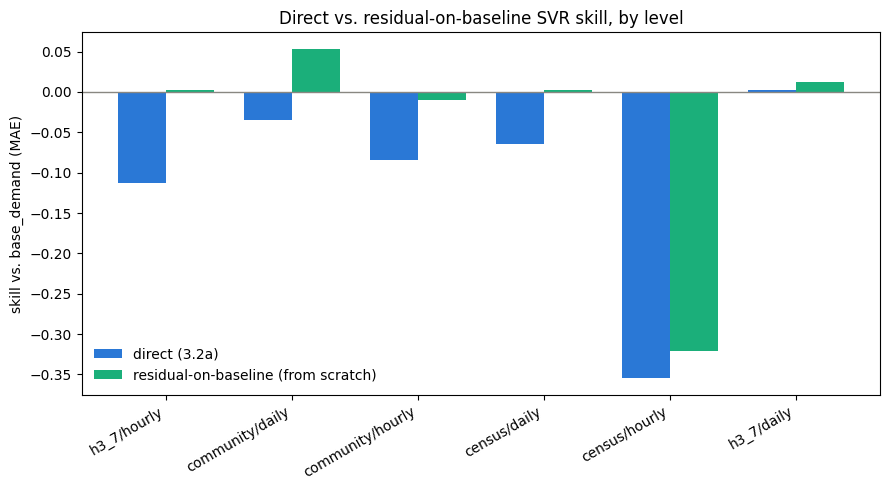

In [10]:
#| label: fig-svr-direct-vs-residual-final
#| fig-cap: "Direct (3.2a) vs. residual-on-baseline (this notebook) SVR skill, both independently tuned, per level."
plot_df = final_comparison.assign(level=final_comparison.spatial + "/" + final_comparison.temporal)
plot_df = plot_df.set_index("level")[["skill_MAE_direct", "skill_MAE_residual"]]

fig, ax = plt.subplots(figsize=(9, 5))
x = np.arange(len(plot_df))
width = 0.38
ax.bar(x - width / 2, plot_df["skill_MAE_direct"], width, label="direct (3.2a)", color="#2a78d6")
ax.bar(x + width / 2, plot_df["skill_MAE_residual"], width, label="residual-on-baseline (from scratch)", color="#1baf7a")
ax.axhline(0, color="#898781", linewidth=1)
ax.set_xticks(x)
ax.set_xticklabels(plot_df.index, rotation=30, ha="right")
ax.set_ylabel("skill vs. base_demand (MAE)")
ax.set_title("Direct vs. residual-on-baseline SVR skill, by level")
ax.legend(frameon=False)
fig.tight_layout()
plt.show()

In [11]:
# Prediction on the test set and saving in parquet files for '3.4\ ModelPerformanceVisualization.ipynb' to evaluate
for spatial, temporal in LEVELS:
    print(f"\n{'-' * 70}\n{spatial} / {temporal}")
    df_test = load_splits(spatial, temporal)[2]
    key = SPATIAL_LEVELS[spatial]

    # Load the winner for this level
    best = joblib.load(SVR_DIR / spatial / temporal / "best.joblib")
    print(f"Loaded winner: {best['feature_set']} ({best['kernel']})")

    # Predict on the test split. The model outputs the RESIDUAL correction
    # log1p(demand) - log1p(base_demand), so counts are reconstructed by adding
    # log1p(base_demand) back BEFORE expm1 -- exactly as the validation path above does.
    # (to_counts(model.predict(...)) alone would return expm1(correction) ~ 0 everywhere,
    # since the correction is centred near zero.)
    X_test = best["scaler"].transform(df_test[best["features"]])
    base_log1p_test = np.log1p(df_test["base_demand"].values)
    log1p_pred_test = np.clip(base_log1p_test + best["model"].predict(X_test), -LOG_CEILING, LOG_CEILING)
    y_test_pred = to_counts(log1p_pred_test)
    df_test["SVR_pred"] = y_test_pred

    # Quick Skill Score on the test split (for information only; 3.4 does the full evaluation)
    y_test_true = df_test[TARGET].values
    base_test = score(y_test_true, df_test["base_demand"].values, "Baseline: historical mean (base_demand)")
    model_test = score(y_test_true, y_test_pred, f"SVR-residual ({best['feature_set']}, {best['kernel']})")
    skill_test = skill(model_test, base_test)
    print(f"test: MAE={model_test['MAE']:.3f}, RMSE={model_test['RMSE']:.3f}, R2={model_test['R2']:.4f}  skill vs base_demand: {skill_test['skill_MAE']:+.1%} MAE")

    # Save the predictions in parquet format for later evaluation in 3.4
    out_dir = MODELS_DIR / "predictions"
    out_dir.mkdir(parents=True, exist_ok=True)
    df_test.to_parquet(out_dir / f"test_pred_{spatial}_{temporal}.parquet", index=False)


----------------------------------------------------------------------
h3_7 / hourly


Loaded winner: basic+weather (linear)


test: MAE=1.016, RMSE=6.480, R2=0.9091  skill vs base_demand: +4.8% MAE



----------------------------------------------------------------------
h3_7 / daily
Loaded winner: basic+poi (linear)


test: MAE=20.639, RMSE=112.374, R2=0.9190  skill vs base_demand: +3.5% MAE

----------------------------------------------------------------------
census / hourly


...


----------------------------------------------------------------------
census / daily
Loaded winner: basic+poi+weather (rbf)


test: MAE=4.881, RMSE=28.609, R2=0.9163  skill vs base_demand: +0.8% MAE

----------------------------------------------------------------------
community / hourly
Loaded winner: basic+poi+weather (rbf)


test: MAE=2.878, RMSE=11.261, R2=0.8988  skill vs base_demand: +0.9% MAE

----------------------------------------------------------------------
community / daily


Loaded winner: basic+weather (linear)


test: MAE=46.337, RMSE=164.692, R2=0.9413  skill vs base_demand: +6.5% MAE
